# 02 用户转化漏斗分析

**目标**：分析用户从浏览到购买的转化路径，找出关键流失节点。

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, clean_data
from src.funnel import overall_funnel, funnel_by_category, plot_funnel, daily_funnel_trend

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 加载数据
df, item_meta = load_data(use_simulated=True, n_users=5000)
df = clean_data(df)

生成模拟数据：5000 个用户...
共 138,206 条行为记录，6 个品类


In [3]:
# === 1. 整体漏斗 ===
funnel_df = overall_funnel(df)
funnel_df

,stage,stage_cn,users,overall_rate_pct,step_rate_pct
0,pv,浏览,5000,100.00,100.00
1,fav,收藏,4619,92.38,92.38
2,cart,加购,3972,79.44,85.99
3,buy,购买,2161,43.22,54.41


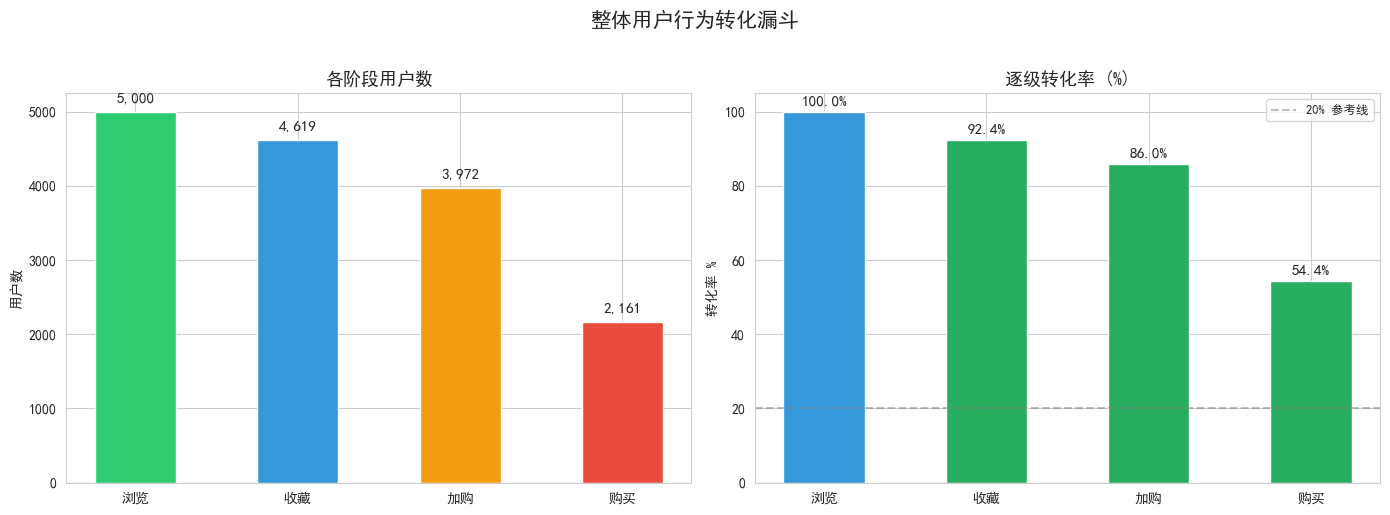

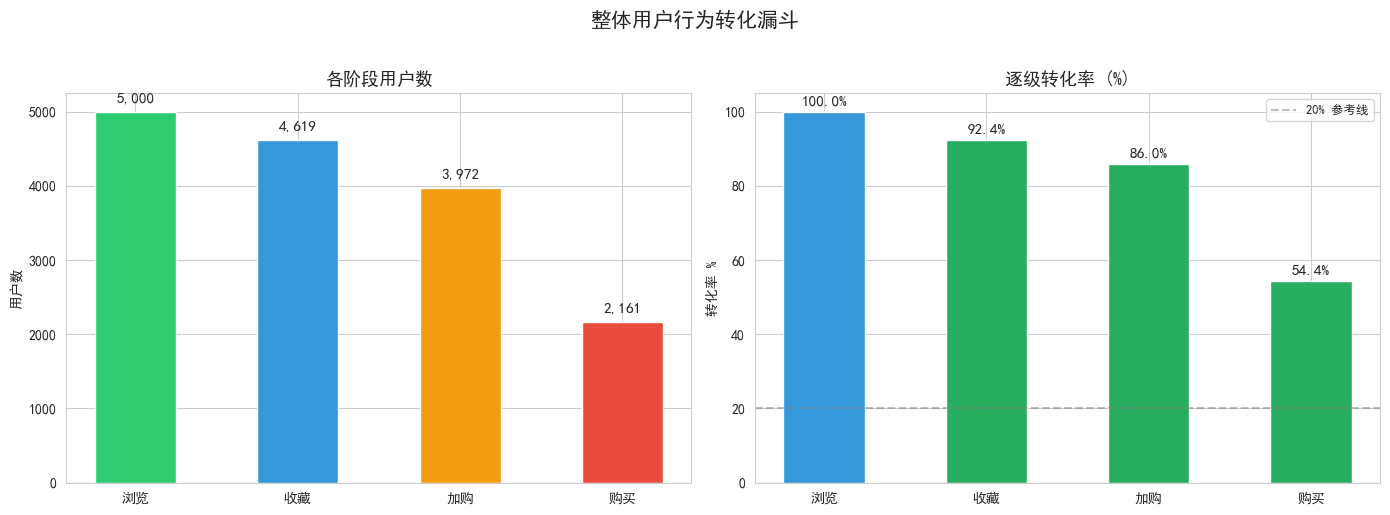

In [4]:
plot_funnel(funnel_df, title='整体用户行为转化漏斗')

各品类最终购买转化率：


,category,overall_rate_pct,users
3,服装,15.48,731
15,食品,14.39,675
23,家居,12.61,573
7,电子产品,11.09,483
11,美妆,9.09,373
19,图书,6.99,254


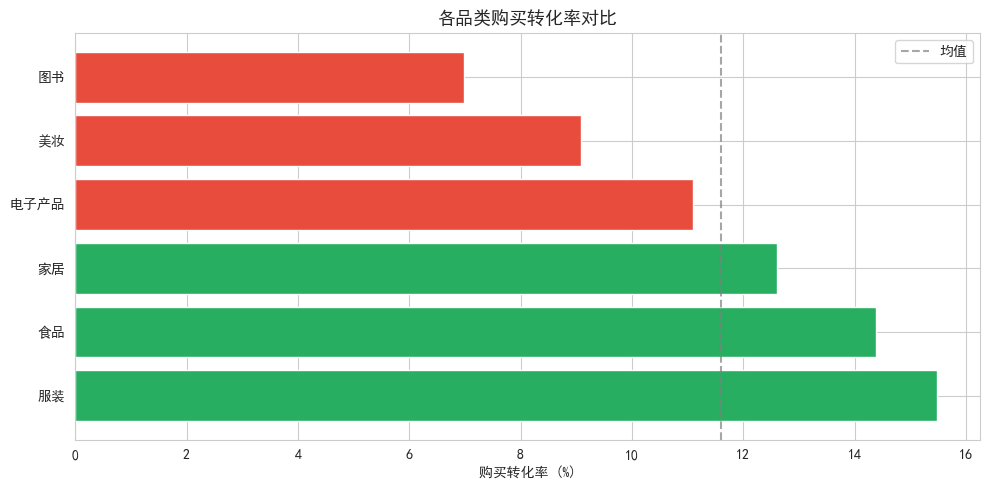

In [5]:
# === 2. 各品类漏斗对比 ===
if item_meta is not None:
    category_funnel = funnel_by_category(df, item_meta)
    
    # 只看各品类的购买转化率
    buy_rates = category_funnel[category_funnel['stage'] == 'buy'].sort_values('overall_rate_pct', ascending=False)
    print('各品类最终购买转化率：')
    display(buy_rates[['category', 'overall_rate_pct', 'users']])
    
    # 可视化
    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if r < buy_rates['overall_rate_pct'].median() else '#27ae60' for r in buy_rates['overall_rate_pct']]
    plt.barh(buy_rates['category'], buy_rates['overall_rate_pct'], color=colors)
    plt.xlabel('购买转化率 (%)')
    plt.title('各品类购买转化率对比', fontsize=13, fontweight='bold')
    plt.axvline(x=buy_rates['overall_rate_pct'].mean(), color='gray', linestyle='--', alpha=0.7, label='均值')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# === 3. 每日漏斗趋势 ===
daily_trend = daily_funnel_trend(df)
print('每日转化率统计：')
daily_trend.describe().round(2)

每日转化率统计：


,total_users,pv_rate,fav_rate,cart_rate,buy_rate
count,61.00,61.0,61.00,61.00,61.00
mean,200.69,100.0,83.73,59.92,23.80
std,29.06,0.0,3.33,8.42,4.00
min,1.00,100.0,77.88,0.00,0.00
25%,197.00,100.0,82.23,58.37,22.27
50%,202.00,100.0,83.82,60.91,24.00
75%,214.00,100.0,84.83,62.31,25.71
max,232.00,100.0,100.00,69.15,31.10


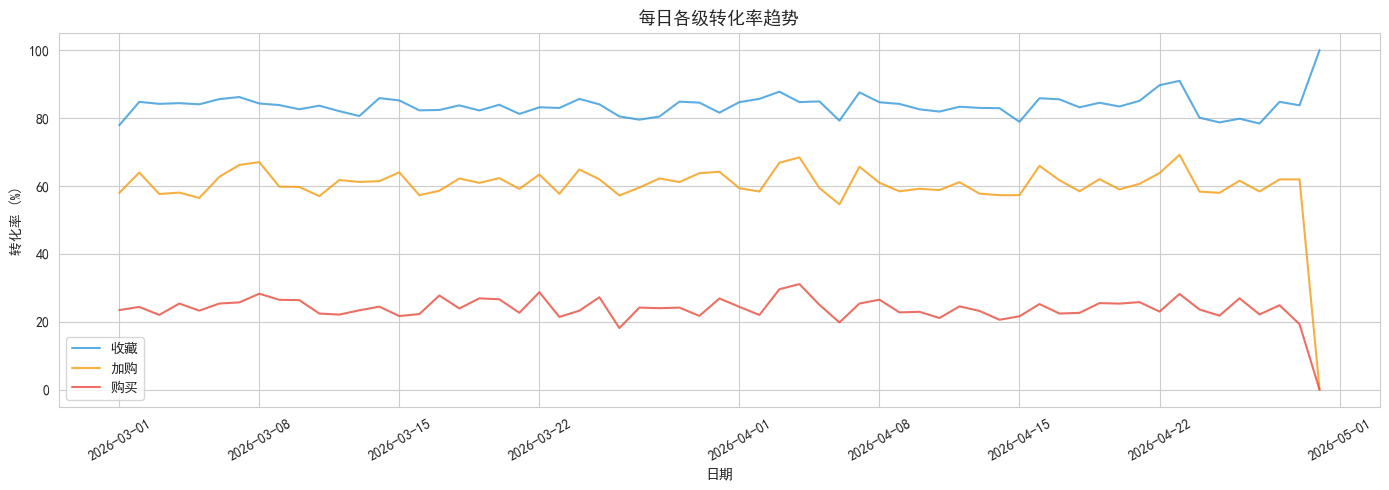

In [7]:
# 可视化每日转化率趋势
fig, ax = plt.subplots(figsize=(14, 5))
for stage, color in zip(['fav_rate', 'cart_rate', 'buy_rate'], ['#3498db', '#f39c12', '#e74c3c']):
    label = {'fav_rate': '收藏', 'cart_rate': '加购', 'buy_rate': '购买'}[stage]
    ax.plot(daily_trend['date'], daily_trend[stage], color=color, linewidth=1.5, label=label, alpha=0.8)
ax.set_xlabel('日期')
ax.set_ylabel('转化率 (%)')
ax.set_title('每日各级转化率趋势', fontsize=13, fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

---
### 本阶段结论
- 整体转化率：浏览→收藏 X%，收藏→加购 Y%，加购→购买 Z%
- 最大流失点在 XX 环节，可能原因：...
- XX 品类转化率最高，YY 品类最低
- 下一步：RFM 用户分层，识别高价值用户